In [3]:
# TODO 
# Simplify the input to be just the drift instead of ILD, ABL
# Simplify the list of parameters, so when we do model fitting, only the unique parameters are passed 
# (i.e. the same t_motor, zero sensory delay for the PA, etc)

import numpy as np
import matplotlib.pyplot as plt
from model_tach_4delays_v1_mu import model_tach_4delays
import timeit
import pandas as pd
# from pybads import BADS


In [4]:
#importing required library
from pandas import read_csv
 
d = read_csv('data.csv')
 
df = d.values

[ 0.13463635 31.3836      1.1275    ] [ 0.1086 82.2049] [40. 30.  0. 30.] [0.00342277 0.         1.        ]
-0.0009969000002456596
-14340.08929702278
mu 0.5 1.0
t_theta 0.004 0.001


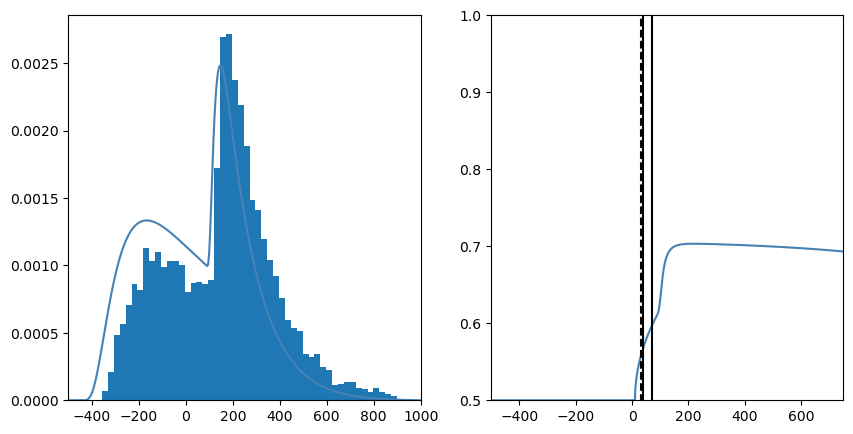

In [5]:

###########################################################################################################

mu_pa = 1.
theta_pa = 1.

mu_tied = 1.
theta_tied = 0.5


tse_TIED = 20.
tmotor =80.

###########################################################################################################
compressive_power = 0.13463634646
a_tied = 31.3836
T0 = 1.1275
v = 0.1086
a = 82.2049
tse_TIED = 40.
tmotor = 30.


###########################################################################################################
# Experimental conditions
# mu
# sigma
# bound 

# ttheta = 1

# abl =
# ild = 
# Params
abl= 40.
ild= 2.
t_fix= 500.
tt=np.arange(-t_fix,1000., 1)

###########################################################################################################
tmotor_TIED = tmotor
tmotor_PA = tmotor
# params are:
# compressive_power, a_tied, T0, v, a, tse_TIED, tmotor_TIED, tse_PA, tmotor_PA, Delta, b, c, d, full_readout, use_Delta
x = [compressive_power, a_tied, T0,  v, a, tse_TIED, tmotor_TIED, 0, tmotor_PA, 0., 0.0034227695, 0., 1.0, True, False]

ndt_TIED = x[5]+x[6]
tse_TIED = x[5]
tmotor_TIED = x[6]

# model = model_tach_shift(ABL=abl,ILD=ild,t_fix=t_fix)
# initialize the model
model = model_tach_4delays(RT=tt,ABL=abl*np.ones_like(tt),ILD=ild*np.ones_like(tt),t_fix=t_fix*np.ones_like(tt),out=1.0*np.ones_like(tt))
model.set_params(x)
model.print_params()



###########################################################################################################
# PA process

model_mu_pa = mu_pa*theta_pa
model_t_theta_pa = 1/theta_pa**2/1000


model.mu_pa = model_mu_pa
model.t_theta_pa = model_t_theta_pa

###########################################################################################################
# TIED

model_mu_tied = mu_tied*theta_tied
model_t_theta_tied = 1/theta_tied**2/1000


model.mu = model.mu/model.mu[0]*model_mu_tied
model.t_theta = model.t_theta/model.t_theta[0]*model_t_theta_tied

###########################################################################################################
# pdf_a, tach = model.pdf_and_tach(x,v,a,abl*np.ones_like(tt),ild*np.ones_like(tt),tt,t_fix*np.ones_like(tt),w_tse,-tse+10)
# pdf_a, tach = model.pdf_and_tach(x, v, a, w_tse, Delta) 
# testing: plot correct and error joint pdfs 
pdf_a, tach, pdf_pa, pdf_tied = model.pdf_and_tach_for_debug()

fig, ax = plt.subplots(1,2)
fig.set_size_inches([10,5])

ax[0].plot(tt, pdf_a, label='correct', color='steelblue')
#ax[0].plot(tt, pdf_a*(1-tach), label='error', color='plum')
ax[0].set_xlim([-t_fix,1000])

ax[1].plot(tt, tach, label='tachometric', color='steelblue')
ax[1].plot(tse_TIED*np.array([1,1]),np.array([0,1]),color='k')
ax[1].plot(tmotor_TIED*np.array([1,1]),np.array([0,1]),color='k',ls='--')
ax[1].plot(ndt_TIED*np.array([1,1]),np.array([0,1]),color='k')
ax[1].set_xlim([-t_fix,750])
ax[1].set_ylim([.5,1])

good_inds = df[:,1]<1.4
ax[0].hist(df[good_inds,1]*1000-t_fix,bins = 50, density = True) 
# testing: log likelihood

# logL_corr, logL_err = model.log_likelihood_both()
# print(np.sum(logL_corr)) 
# print(np.sum(logL_err))

start = timeit.timeit()
logL = model.log_likelihood()
end = timeit.timeit()
print(end - start)
print(np.sum(logL))
print('mu', model.mu[0], model.mu_pa)
print('t_theta',model.t_theta[0], model.t_theta_pa)


Text(0.5, 1.0, 'PA')

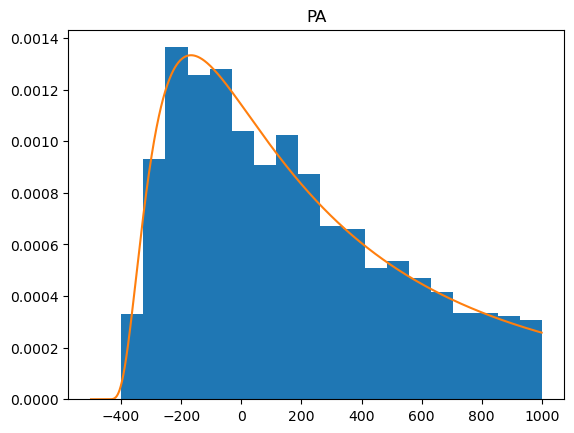

In [6]:
dt = 0.001
ntrials = 5000
ts = []


for i in range(ntrials):
    all_x = []
    x = 0.
    running = True
    count = 0
    while running:
        x = x + dt*mu_pa + np.random.normal(0,np.sqrt(1*dt))
        all_x.append(x)
        count +=1
        if x >= theta_pa:
            running = False
        a
    #f count<= 140:
    ts.append(count)
ts = np.array(ts)
ts
RT_PA = ts-t_fix+tmotor

plt.hist(ts-t_fix+tmotor, bins = np.linspace(-400,1000,20), density=True) 
plt.plot(tt,pdf_pa)
plt.title('PA')

In [7]:
# print('mu', model.mu[0])
# print('t_theta',model.t_theta[0])
# theta_re = np.sqrt(1/(model.t_theta[0]*1000))
# mu_re = model.mu[0] /theta_re
# print(mu_pa, theta_pa)


Text(0.5, 1.0, 'Reactive')

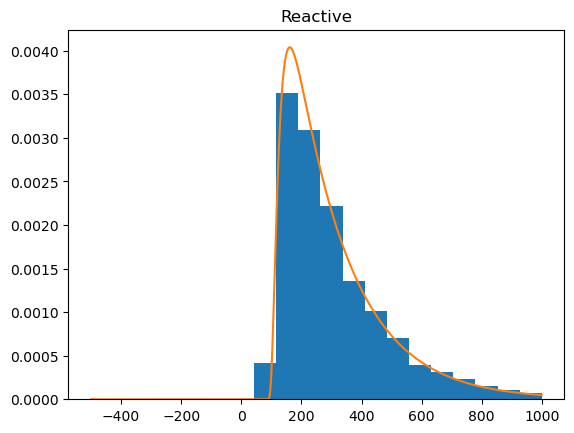

In [8]:

dt = 0.001
ntrials = 5000
ts = []


for i in range(ntrials):
    all_x = []
    x = 0.
    running = True
    count = 0
    while running:
        x = x + dt*mu_tied + np.random.normal(0,np.sqrt(1*dt))
        all_x.append(x)
        count +=1
        if np.abs(x) >= theta_tied:
            running = False
        a
    #f count<= 140:
    ts.append(count)
ts = np.array(ts)
ts

RT_TIED = ts+tmotor+tse_TIED
plt.hist(ts+tmotor+tse_TIED, bins = np.linspace(-400,1000,20), density=True) 
plt.plot(tt,pdf_tied)
plt.title('Reactive')

In [89]:
# INITIALIZE THE MODEL
###########################################################################################################

mu_pa = 1.
theta_pa = 1.

mu_tied = 1.
theta_tied = 0.5


tse_TIED = 20.
tmotor = 80.

###########################################################################################################
compressive_power = 0.1661
a_tied = 31.3836
T0 = 1.1275
v = 0.1086
a = 82.2049
tse_TIED = 40.
tmotor = 30.


###########################################################################################################
# Experimental conditions
# mu
# sigma
# bound 

# ttheta = 1

# abl =
# ild = 
# Params
abl= 40.
ild= 2.
t_fix= 500.
tt=np.arange(-t_fix,1000., 1)

###########################################################################################################
tmotor_TIED = tmotor
tmotor_PA = tmotor
# params are:
# compressive_power, a_tied, T0, v, a, tse_TIED, tmotor_TIED, tse_PA, tmotor_PA, Delta, b, c, d, full_readout, use_Delta
x = [compressive_power, a_tied, T0,  v, a, tse_TIED, tmotor_TIED, 0, tmotor_PA, 0., 0.0034227695, 0., 1.0, True, False]

ndt_TIED = x[5]+x[6]
tse_TIED = x[5]
tmotor_TIED = x[6]

# model = model_tach_shift(ABL=abl,ILD=ild,t_fix=t_fix)
# initialize the model
model = model_tach_4delays(RT=tt,ABL=abl*np.ones_like(tt),ILD=ild*np.ones_like(tt),t_fix=t_fix*np.ones_like(tt),out=1.0*np.ones_like(tt))
model.set_params(x)
model.print_params()


###########################################################################################################
# PA process

model_mu_pa = mu_pa*theta_pa
model_t_theta_pa = 1/theta_pa**2/1000


model.mu_pa = model_mu_pa
model.t_theta_pa = model_t_theta_pa

###########################################################################################################
# TIED


model_mu_tied = mu_tied*theta_tied
model_t_theta_tied = 1/theta_tied**2/1000




###########################################################################################################
# UPDATES THE MODEL WITH DATA AND USER PARAMS

len_data = len(df)
model.RT = df[:,1]
model.t_fix = t_fix*np.ones(len_data)
model.out = df[:,2]

model.mu = np.ones(len_data)*model_mu_tied
model.t_theta = np.ones(len_data)*model_t_theta_tied

print('mu', model.mu[0], model.mu_pa)
print('t_theta',model.t_theta[0], model.t_theta_pa)


[ 0.1661 31.3836  1.1275] [ 0.1086 82.2049] [40. 30.  0. 30.] [0.00342277 0.         1.        ]
mu 0.5 1.0
t_theta 0.004 0.001


In [90]:
def total_log_likelihood(params):
    # rt_vect=np.array(data['RT_ms'])
    # abl_vect=np.array(data['ABL'])
    # ild_vect=np.array(data['|ILD|'])
    # fix_vect=np.array(data['intended_fix_ms'])
    # out_vect=np.array(data['success'])
    # model = model_tach_4delays(RT=rt_vect,ABL=abl_vect,ILD=ild_vect,t_fix=fix_vect, out=out_vect)
    model.set_params_alexis(params)   # You will have to create this function in the other script
    logL = model.log_likelihood()
    return np.sum(logL)

In [91]:
def objective_function(params):
    """ 
    Compute the negative log-likelihood for the DDM parameters.
    
    :param params: array of model parameters [v, a, x1, x2, x3, x4]
    :param data: DataFrame with the experimental data
    :return: Negative log-likelihood

    """ # Assuming x includes 4 parameters
    # Calculate the total log likelihood using the defined function
    # BADS minimizes the function, so return negative log likelihood
    return -total_log_likelihood(params)
#create a suitable function for bads

def objective_fun_forbads(params):
    # data = df_data
    return objective_function(params)

In [92]:
#Choose the initial parameters for your model
# Below you have an example for 
# x = [tmotor, tse_TIED, T0, ndt]
# 
initial_params = [100, 40]

# You also have to define search places for the BADS
# The Hard bounds are the maximum and mimimum values that will be tried
# the plausible_lb and plausible_ub are the most plausible lower bounds and upper bounds respectively
# in which the algorithm will search for a solution.
# You can make them equal to the hard bounds as a start

#              lambda a_tied  T0    ndt  v     a_pa  w_tse  Delta
lower_bounds = [0, 0]  # Hard lower bounds
upper_bounds = [140,  60]  # Hard upper bounds
plausible_lb = [0, 0]  # Plausible lower bounds
plausible_ub = [140, 60]  # Plausible upper bounds



In [93]:
# Running the fitting! Will fail until you define the function set_params_alexis
best_result = None
print(f"Starting optimization with initial params: {initial_params}")
bads = BADS(objective_fun_forbads, initial_params, lower_bounds, upper_bounds, plausible_lb, plausible_ub)
optimize_result = bads.optimize()
result_details = {
    'initial_params': str(initial_params),
    'optimized_params': str(optimize_result.x),
    'result_fun': optimize_result.fval,
    }
print(f"Optimization result: {optimize_result.x}, {optimize_result.fval}")

Starting optimization with initial params: [100, 40]
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
Beginning optimization of a DETERMINISTIC objective function

 Iteration    f-count         f(x)           MeshScale          Method             Actions
     0           2         72852.6               1                                 Uncertainty test


     0           6         71127.4               1         Initial mesh            Initial points
     0           8         71127.4             0.5         Refine grid             Train
     1           9         71084.7             0.5     Successful search (ES-wcm)        
     1          19         71084.7            0.25         Refine grid             Train
     2          26         71084.7           0.125         Refine grid             Train
     3          27         71084.6           0.125     Successful search (ES-wcm)        
     3          37         71084.6          0.0625         Refine grid             


/home/tjpc/anaconda3/envs/snn_env/lib/python3.10/site-packages/pybads/bads/bads.py:2038: RuntimeWarning: invalid value encountered in divide
  gamma_z = (


     4          44         71084.6         0.03125         Refine grid             


/home/tjpc/anaconda3/envs/snn_env/lib/python3.10/site-packages/pybads/bads/bads.py:2340: RuntimeWarning: overflow encountered in square
  total = np.sum(zscore**2)


     5          51         71084.6        0.015625         Refine grid             Train
     6          58         71084.6      0.00390625         Refine grid             Train
     7          59         71084.6      0.00390625     Incremental search (ES-ell)        
     7          60         71084.6      0.00390625     Successful search (ES-ell)        
     7          69         71084.6      0.00195312         Refine grid             
     8          70         71084.6      0.00195312     Incremental search (ES-wcm)        
     8          76         71084.6     0.000976562         Refine grid             
     9          77         71084.6     0.000976562     Incremental search (ES-ell)        
     9          83         71084.6     0.000488281         Refine grid             Train
    10          90         71084.6      0.00012207         Refine grid             Train
    11          97         71084.6     3.05176e-05         Refine grid             Train
Optimization terminated: